<a href="https://colab.research.google.com/github/jooshmora/01-codepilot/blob/main/CS170_Assignment1_JoshuaMora.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### General Search Pseudocode

```
function general-search(problem, QUEUEING-FUNCTION)
    nodes = MAKE-QUEUE(MAKE NODE(problem.INITIAL-STATE))
    loop do
        if EMPTY(nodes) then return "failure"
        node = REMOVE FRONT(nodes)
        if problem.GOALTEST(node.STATE) succeeds then return node
        nodes = QUEUEING
            FUNCTION(nodes, EXPAND(node, problem.OPERATORS))
end

In [70]:
import heapq

#The dictionary moves defines the possible moves for the blank tile (0) in the 8-puzzle game.
#Each key is a move direction (up, down, left, right) and the value
goal_state = [1, 2, 3, 4, 5, 6, 7, 8, 0]

In [71]:
moves = {
    'up': -3, #move up
    'down': 3, #move down
    'left': -1, #move left
    'right': 1 #move right
}

In [72]:
#Class to represent the state of the puzzle,
# including the board configuration, parent state,
# move that led to this state, depth in the search tree,
# and cost for A* search.
class BoardState:
    def __init__(state, board, parent, move, depth, cost):
        state.board = board
        state.parent = parent
        state.move = move
        state.depth = depth
        state.cost = cost
        #Tells the heap how to compare states based on cost for A* search
    def __lt__(state, other):
        return state.cost < other.cost

In [73]:
#Function to print the current state of the board
def print_board(board):
    print("+---+---+---+")
    for row in range(0, 9, 3):
        row_visual = "|"
        for tile in board[row:row + 3]:
            cell = " " if tile == 0 else str(tile)
            row_visual += f" {cell} |"
        print(row_visual)
    print("+---+---+---+")

In [74]:
#Function to return a new board state after moving the blank tile
#in the specified direction
def move_tile(board, move, blank_pos):
    new_board = board[:]
    new_blank_pos = blank_pos + moves[move]
    new_board[blank_pos], new_board[new_blank_pos] = new_board[new_blank_pos], new_board[blank_pos]
    return new_board

In [75]:
# Generate successor boards (operators) from a given state.
def operators(board):
    blank_pos = board.index(0)
    successors = []

    for move in moves:
        if move == 'up' and blank_pos < 3:
            continue
        if move == 'down' and blank_pos > 5:
            continue
        if move == 'left' and blank_pos % 3 == 0:
            continue
        if move == 'right' and blank_pos % 3 == 2:
            continue

        new_board = move_tile(board, move, blank_pos)
        successors.append((move, new_board))

    return successors

In [76]:
# Manhattan-distance heuristic for 8-puzzle. Pulled from geeksforgeeks.org
def manhattan_distance(board):
    distance = 0
    for i in range(9):
        tile = board[i]
        if tile != 0:
            target_pos = tile - 1
            current_row, current_col = divmod(i, 3)
            target_row, target_col = divmod(target_pos, 3)
            distance += abs(current_row - target_row) + abs(current_col - target_col)
    return distance

# Misplaced-tiles heuristic for 8-puzzle. Pulled from geeksforgeeks.org
def misplaced_tiles(board):
    count = 0
    for i in range(9):
        tile = board[i]
        if tile != 0 and tile != goal_state[i]:
            count += 1
    return count

In [77]:
#Print solution function traces the steps from the goal state back to the
#initial state by following the parent pointers. It prints each move and
#the board configuration. Queue manipulation pulled from geeksforgeeks.org
def print_solution(solution_state):
    path = []
    current = solution_state
    while current:
        path.append(current)
        current = current.parent
    path.reverse()

    for state in path:
        print(f"Move: {state.move}")
        print_board(state.board)

In [78]:
# A* search
def a_star_search(problem, queueing_function):
    # Priority queue ordered by estimated cost f(n) = g(n) + h(n).
    open_list = []
    closed_list = set()
    heapq.heappush(open_list, BoardState(problem, None, None, 0, queueing_function(problem)))
    expanded = 0
    max_queue_size = len(open_list)

    # Main search loop: continue until queue is empty.
    while open_list:
        # Always expand the lowest-cost node next.
        node = heapq.heappop(open_list)
        expanded += 1

        # Goal test: stop as soon as goal state is reached.
        if node.board == goal_state:
            return node, expanded, max_queue_size

        # Record this state as visited to avoid re-expansion.
        closed_list.add(tuple(node.board))

        # Expand node using the operator function (successors).
        for move, new_board in operators(node.board):
            # Skip states we've already visited.
            if tuple(new_board) in closed_list:
                continue

            # Child cost uses path depth plus heuristic estimate.
            child = BoardState(new_board, node, move, node.depth + 1,
                node.depth + 1 + queueing_function(new_board),
            )
            # Push the child into the priority queue.
            heapq.heappush(open_list, child)

        # Track the maximum size of the queue during search.
        if len(open_list) > max_queue_size:
            max_queue_size = len(open_list)

    # If the queue empties, no solution was found.
    return None, expanded, max_queue_size

In [79]:
#Interface for custom initial state and heuristic choice.
def parse_state(text):
    cleaned = text.replace(",", " ").split()
    numbers = [int(value) for value in cleaned]
    if len(numbers) != 9:
        raise ValueError("Enter exactly 9 numbers (0-8) for the board state.")
    if set(numbers) != set(range(9)):
        raise ValueError("State must contain each number 0-8 exactly once.")
    return numbers

In [80]:
def choose_heuristic():
    print("Choose search strategy:")
    print("1) Uniform cost search")
    print("2) A* with misplaced tiles")
    print("3) A* with Manhattan distance")
    choice = input("Enter 1, 2, or 3: ").strip()
    if choice == "1":
        return "Uniform cost", lambda board: 0
    if choice == "2":
        return "A* misplaced tiles", misplaced_tiles
    if choice == "3":
        return "A* Manhattan", manhattan_distance
    raise ValueError("Invalid choice. Enter 1, 2, or 3.")

In [81]:
try: #Function that prompts user to enter an initial state and chooose a heuristic
    state_input = input("Enter initial state (9 numbers, 0 is blank): ")
    initial_custom = parse_state(state_input)
    strategy_name, heuristic_fn = choose_heuristic()
    solution, expanded, max_queue = a_star_search(initial_custom, heuristic_fn)
    depth = solution.depth if solution else None

    #Prints details to the user about search results
    print("Strategy:", strategy_name)
    print("Solution depth:", depth)
    print("Nodes expanded:", expanded)
    print("Max queue size:", max_queue)

    #If a solution was found, print the moves it took until reaching the goal state
    if solution:
        print_solution(solution)
        print_board(solution.board)
    else:
        print("No solution found.")
except ValueError as exc:
    print("Input error:", exc)

Enter initial state (9 numbers, 0 is blank): 0 7 2 4 6 1 3 5 8
Choose search strategy:
1) Uniform cost search
2) A* with misplaced tiles
3) A* with Manhattan distance
Enter 1, 2, or 3: 3
Strategy: A* Manhattan
Solution depth: 24
Nodes expanded: 1302
Max queue size: 794
Move: None
+---+---+---+
|   | 7 | 2 |
| 4 | 6 | 1 |
| 3 | 5 | 8 |
+---+---+---+
Move: right
+---+---+---+
| 7 |   | 2 |
| 4 | 6 | 1 |
| 3 | 5 | 8 |
+---+---+---+
Move: down
+---+---+---+
| 7 | 6 | 2 |
| 4 |   | 1 |
| 3 | 5 | 8 |
+---+---+---+
Move: left
+---+---+---+
| 7 | 6 | 2 |
|   | 4 | 1 |
| 3 | 5 | 8 |
+---+---+---+
Move: down
+---+---+---+
| 7 | 6 | 2 |
| 3 | 4 | 1 |
|   | 5 | 8 |
+---+---+---+
Move: right
+---+---+---+
| 7 | 6 | 2 |
| 3 | 4 | 1 |
| 5 |   | 8 |
+---+---+---+
Move: up
+---+---+---+
| 7 | 6 | 2 |
| 3 |   | 1 |
| 5 | 4 | 8 |
+---+---+---+
Move: right
+---+---+---+
| 7 | 6 | 2 |
| 3 | 1 |   |
| 5 | 4 | 8 |
+---+---+---+
Move: up
+---+---+---+
| 7 | 6 |   |
| 3 | 1 | 2 |
| 5 | 4 | 8 |
+---+---+---+
Mo

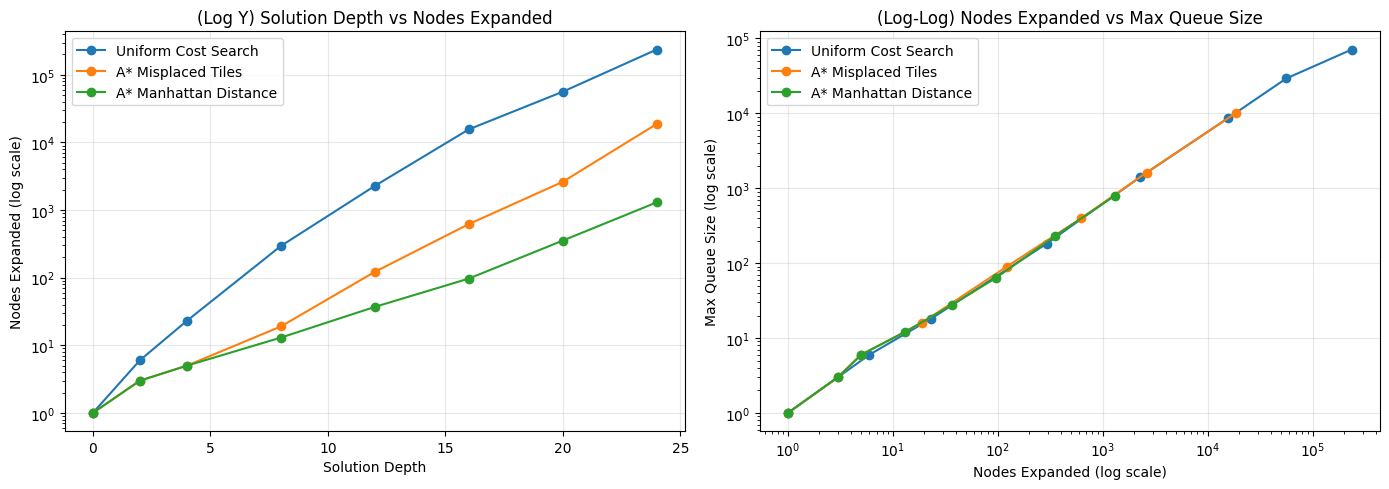


Uniform Cost Search
State # | Depth | Expanded | Max Queue
      1 |     0 |        1 |         1
      2 |     2 |        6 |         6
      3 |     4 |       23 |        18
      4 |     8 |      294 |       183
      5 |    12 |     2277 |      1411
      6 |    16 |    15611 |      8629
      7 |    20 |    56272 |     29290
      8 |    24 |   236705 |     71272

A* Misplaced Tiles
State # | Depth | Expanded | Max Queue
      1 |     0 |        1 |         1
      2 |     2 |        3 |         3
      3 |     4 |        5 |         6
      4 |     8 |       19 |        16
      5 |    12 |      122 |        90
      6 |    16 |      620 |       395
      7 |    20 |     2620 |      1624
      8 |    24 |    18776 |     10199

A* Manhattan Distance
State # | Depth | Expanded | Max Queue
      1 |     0 |        1 |         1
      2 |     2 |        3 |         3
      3 |     4 |        5 |         6
      4 |     8 |       13 |        12
      5 |    12 |       37 |        28


In [83]:
# Log-scale comparison plots
import matplotlib.pyplot as plt

if "results" not in globals():
    benchmark_states = [
        [1, 2, 3, 4, 5, 6, 7, 8, 0],
        [1, 2, 3, 4, 5, 6, 0, 7, 8],
        [1, 2, 3, 5, 0, 6, 4, 7, 8],
        [1, 3, 6, 5, 0, 2, 4, 7, 8],
        [1, 3, 6, 5, 0, 7, 4, 8, 2],
        [1, 6, 7, 5, 0, 3, 4, 8, 2],
        [7, 1, 2, 4, 8, 5, 6, 3, 0],
        [0, 7, 2, 4, 6, 1, 3, 5, 8],
    ]
    algorithms = [
        ("Uniform Cost Search", lambda board: 0),
        ("A* Misplaced Tiles", misplaced_tiles),
        ("A* Manhattan Distance", manhattan_distance),
    ]
    results = {name: {"depth": [], "expanded": [], "max_queue": []} for name, _ in algorithms}
    for name, heuristic in algorithms:
        for state in benchmark_states:
            solution, expanded, max_queue = a_star_search(state, heuristic)
            depth = solution.depth if solution else None
            results[name]["depth"].append(depth)
            results[name]["expanded"].append(expanded)
            results[name]["max_queue"].append(max_queue)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name in results:
    axes[0].plot(results[name]["depth"], results[name]["expanded"], marker="o", label=name)
axes[0].set_yscale("log")
axes[0].set_title("(Log Y) Solution Depth vs Nodes Expanded")
axes[0].set_xlabel("Solution Depth")
axes[0].set_ylabel("Nodes Expanded (log scale)")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

for name in results:
    axes[1].plot(results[name]["expanded"], results[name]["max_queue"], marker="o", label=name)
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_title("(Log-Log) Nodes Expanded vs Max Queue Size")
axes[1].set_xlabel("Nodes Expanded (log scale)")
axes[1].set_ylabel("Max Queue Size (log scale)")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

# Table printouts for clear comparison of results
for name in results:
    print(f"\n{name}")
    print("State # | Depth | Expanded | Max Queue")
    for idx in range(len(benchmark_states)):
        print(
            f"{idx + 1:>7} | {results[name]['depth'][idx]:>5} | {results[name]['expanded'][idx]:>8} | {results[name]['max_queue'][idx]:>9}"
        )